# 🌺 **Floral Traits That Influence Bee Interactions** 🐝







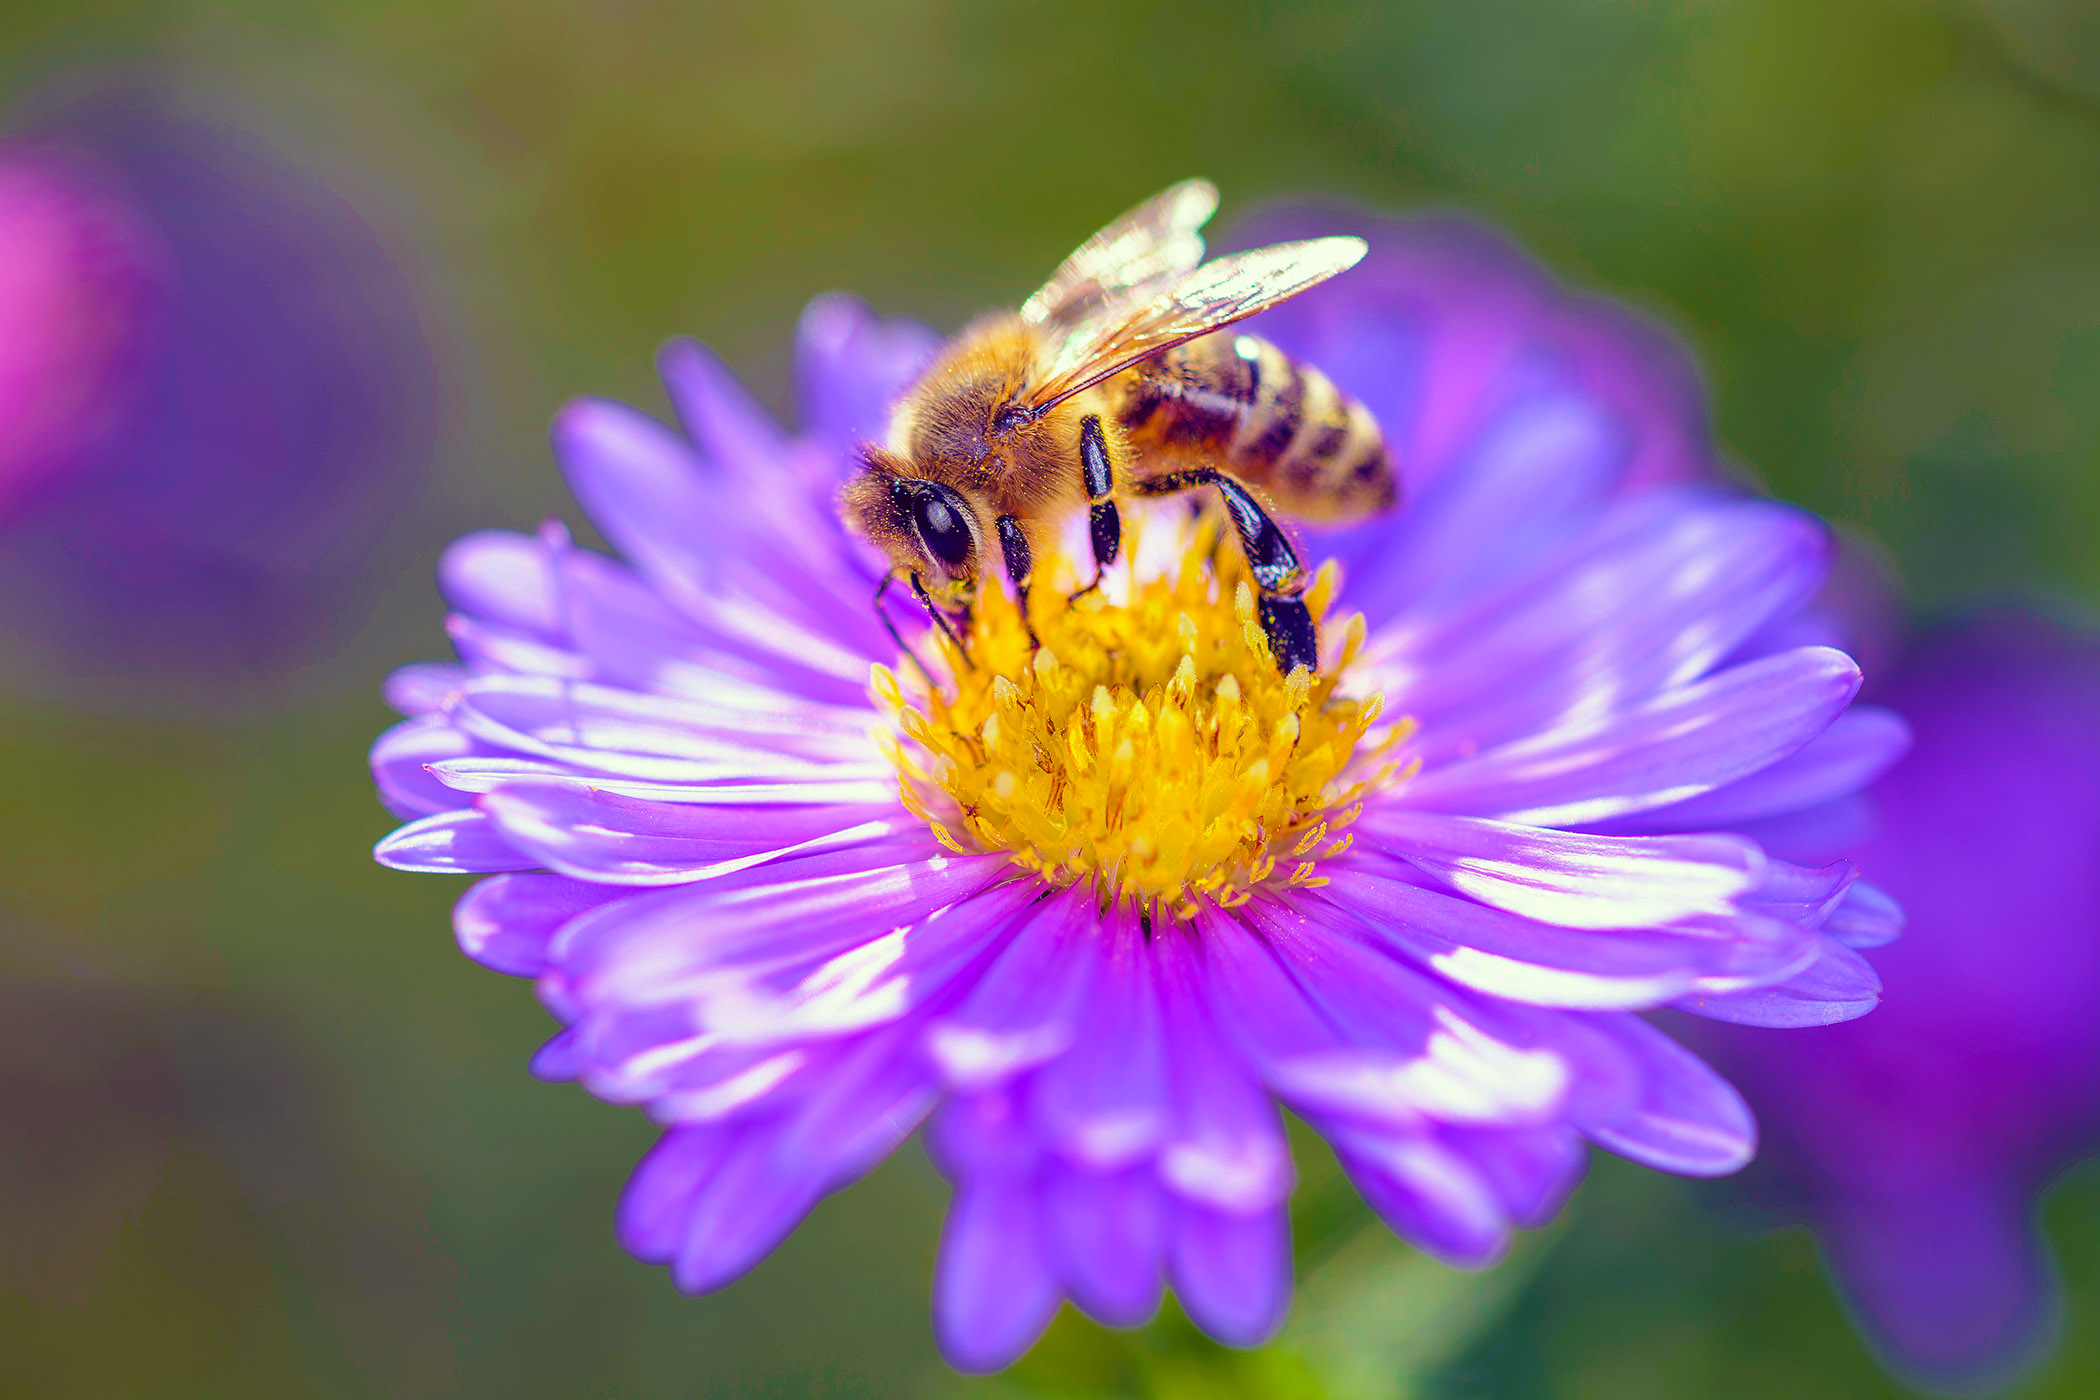

## Pollinators are disappearing, and the ecosystems that depend on them are fading with them.

In this project, I explore how flower characteristics (color, shape, corolla length, and nectar availability) influence bee visitation patterns. (Nectar volume is measured in microliters (µL), a very small unit commonly used in plant biology.) By analyzing real‑world pollinator data, I uncover which flowers attract the highest diversity of bees and how these relationships can guide conservation efforts. This project blends environmental science with data storytelling to highlight how small ecological choices can create meaningful impact.

## 📝 Why I Made My Own Dataset
I built this dataset myself because no existing source included the specific floral traits I needed (corolla length, nectar volume, symmetry, and color) all in one place. Designing it from scratch let me control the structure, set realistic ecological ranges, and avoid messy data issues like missing values or duplicates. Since the dataset was intentionally created clean, the focus of this project is on feature engineering and modeling pollinator interactions.

## 🌱 Initialization

In [3]:
# @title
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.colors import LinearSegmentedColormap

from IPython.display import Image, display

# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/bee_flower_interactions.csv')

# Common name mappings
bee_common_names = {
    "Apis mellifera": "Western Honey Bee",
    "Apis cerana": "Asian Honey Bee",
    "Bombus terrestris": "Buff-tailed Bumblebee",
    "Bombus impatiens": "Common Eastern Bumblebee",
    "Bombus pascuorum": "Common Carder Bee",
    "Bombus lapidarius": "Red-tailed Bumblebee",
    "Osmia bicornis": "Red Mason Bee",
    "Osmia lignaria": "Blue Orchard Mason Bee",
    "Megachile rotundata": "Alfalfa Leafcutter Bee",
    "Andrena fulva": "Tawny Mining Bee"
}

flower_common_names = {
    "Bellis perennis": "Common Daisy",
    "Taraxacum officinale": "Dandelion",
    "Helianthus annuus": "Sunflower",
    "Lavandula angustifolia": "Lavender",
    "Salvia officinalis": "Sage",
    "Digitalis purpurea": "Foxglove",
    "Trifolium pratense": "Red Clover",
    "Phacelia tanacetifolia": "Lacy Phacelia",
    "Campanula rotundifolia": "Harebell",
    "Echium vulgare": "Viper's Bugloss"
}

df['bee_common_name'] = df['bee_species'].map(bee_common_names)
df['flower_common_name'] = df['flower_species'].map(flower_common_names)

# Palette
flower_palette = {
    'white': '#FFFFFF',
    'yellow': '#FFD700',
    'purple': '#800080',
    'pink': '#FF69B4',
    'blue': '#8ECFFF'
}

# Petal Marker
theta = np.linspace(0, 2*np.pi, 100)
r = 1 + 0.3*np.sin(5*theta)
x = r * np.cos(theta)
y = r * np.sin(theta)
flower_marker = Path(np.column_stack([x, y]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 🌼 Feature Engineering
To better understand how bees interact with flowers, I created ecological features that capture meaningful biological patterns. These engineered traits help reveal deeper relationships between pollinators and floral characteristics.

In [4]:
# @title
# 🌼 Corolla Length Category
df['corolla_category'] = pd.cut(
    df['corolla_length_mm'],
    bins=[0, 8, 15, 40],
    labels=['short', 'medium', 'long']
)

# 🍯 Nectar Level (low / medium / high)
df['nectar_level'] = pd.qcut(
    df['nectar_volume_uL'],
    q=3,
    labels=['low', 'medium', 'high']
)

# 🐝 Bee Functional Group
df['bee_group'] = df['bee_species'].apply(
    lambda x: 'honeybee' if 'Apis' in x
    else 'bumblebee' if 'Bombus' in x
    else 'solitary'
)

# 🎨 Flower Color Group
df['color_group'] = df['flower_color'].replace({
    'yellow': 'warm',
    'pink': 'warm',
    'purple': 'cool',
    'blue': 'cool',
    'white': 'neutral'
})

# 🔁 Symmetry Encoding
df['symmetry_encoded'] = df['symmetry'].map({'radial': 0, 'bilateral': 1})

# 🎯 Interaction Strength Category
df['interaction_strength'] = pd.cut(
    df['interaction_probability'],
    bins=[0, 0.33, 0.66, 1],
    labels=['low', 'medium', 'high']
)

## 📁 Save Processed Dataset to Google Drive


In [5]:
# @title
df.to_csv('/content/drive/MyDrive/processed_bee_flower_interactions.csv', index=False)
print("Processed DataFrame saved to Google Drive as 'processed_bee_flower_interactions.csv'")

Processed DataFrame saved to Google Drive as 'processed_bee_flower_interactions.csv'


## 🐝 How Bees Respond to Flower Traits 🌸


*Bee comparison graphic sourced from the web for educational reference.*

This visualization explores how nectar rewards and corolla length affect bee visitation patterns across different pollinator groups.

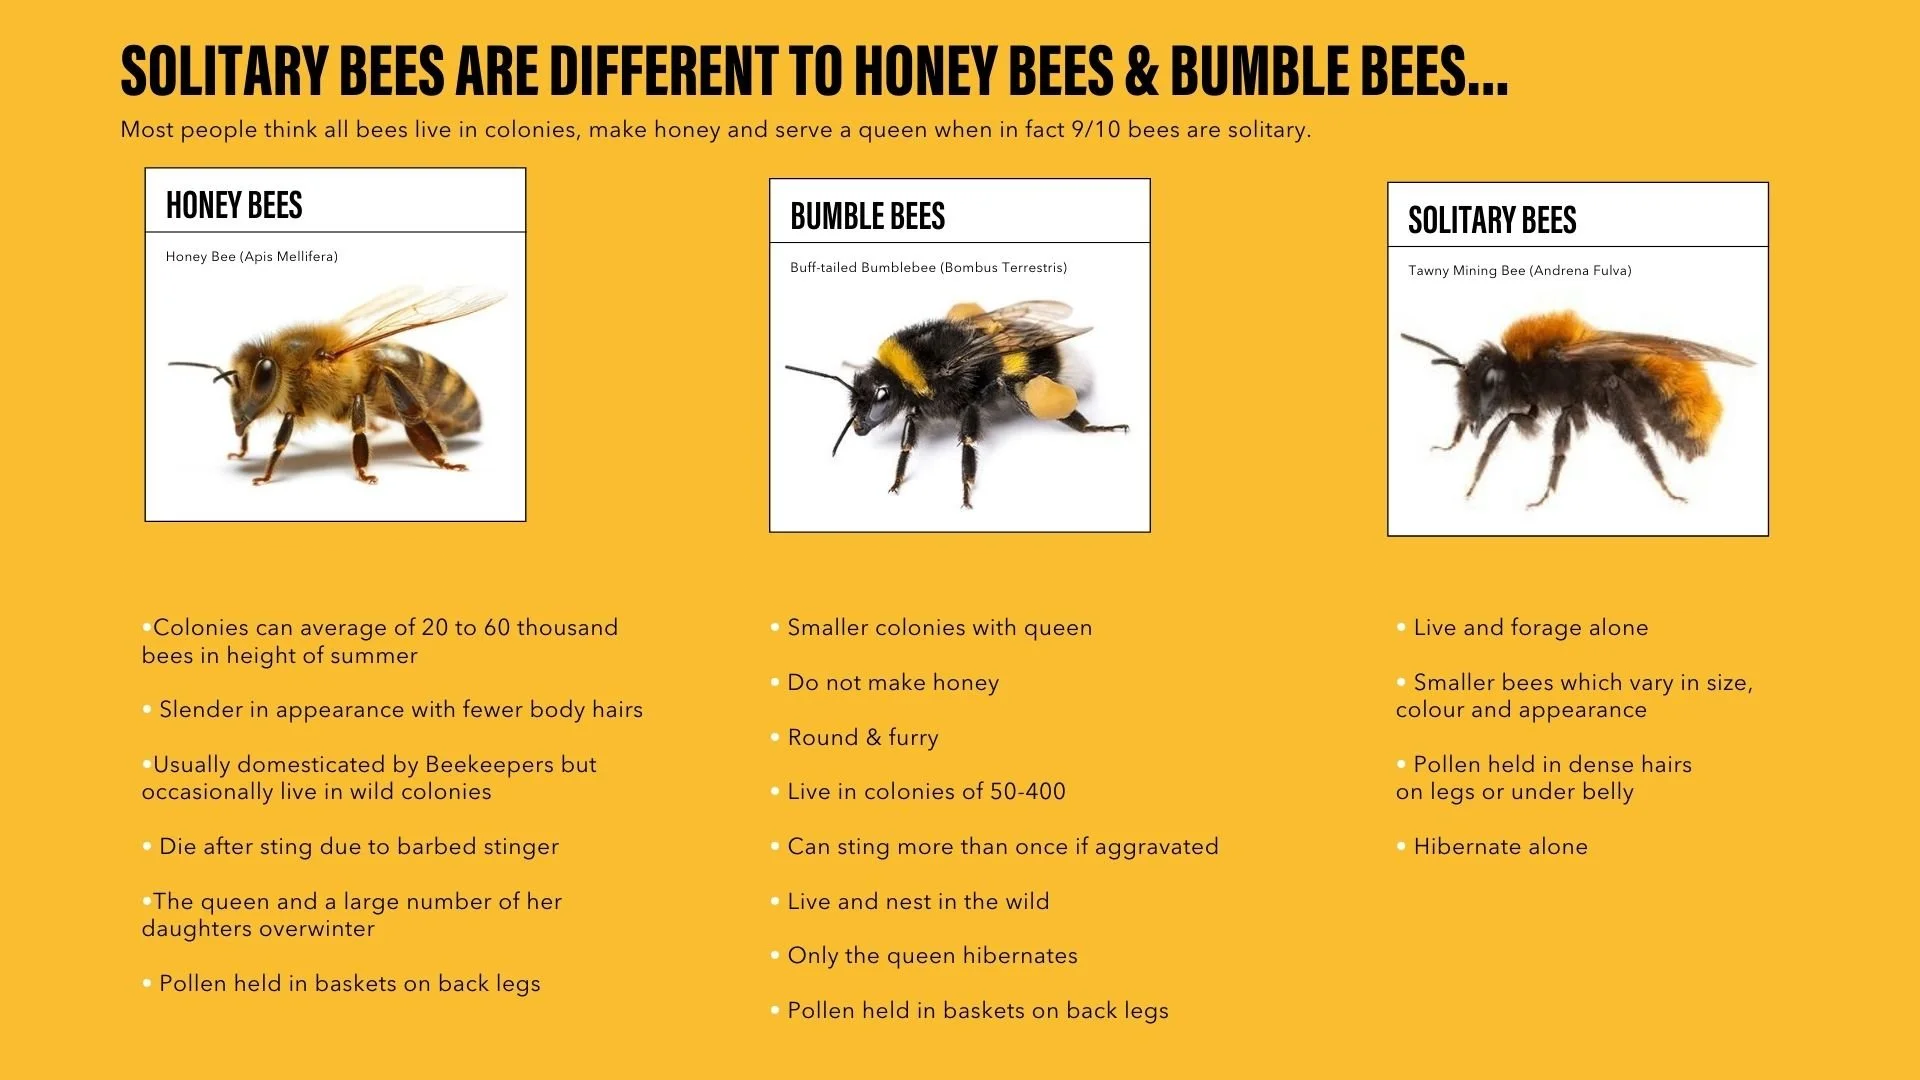

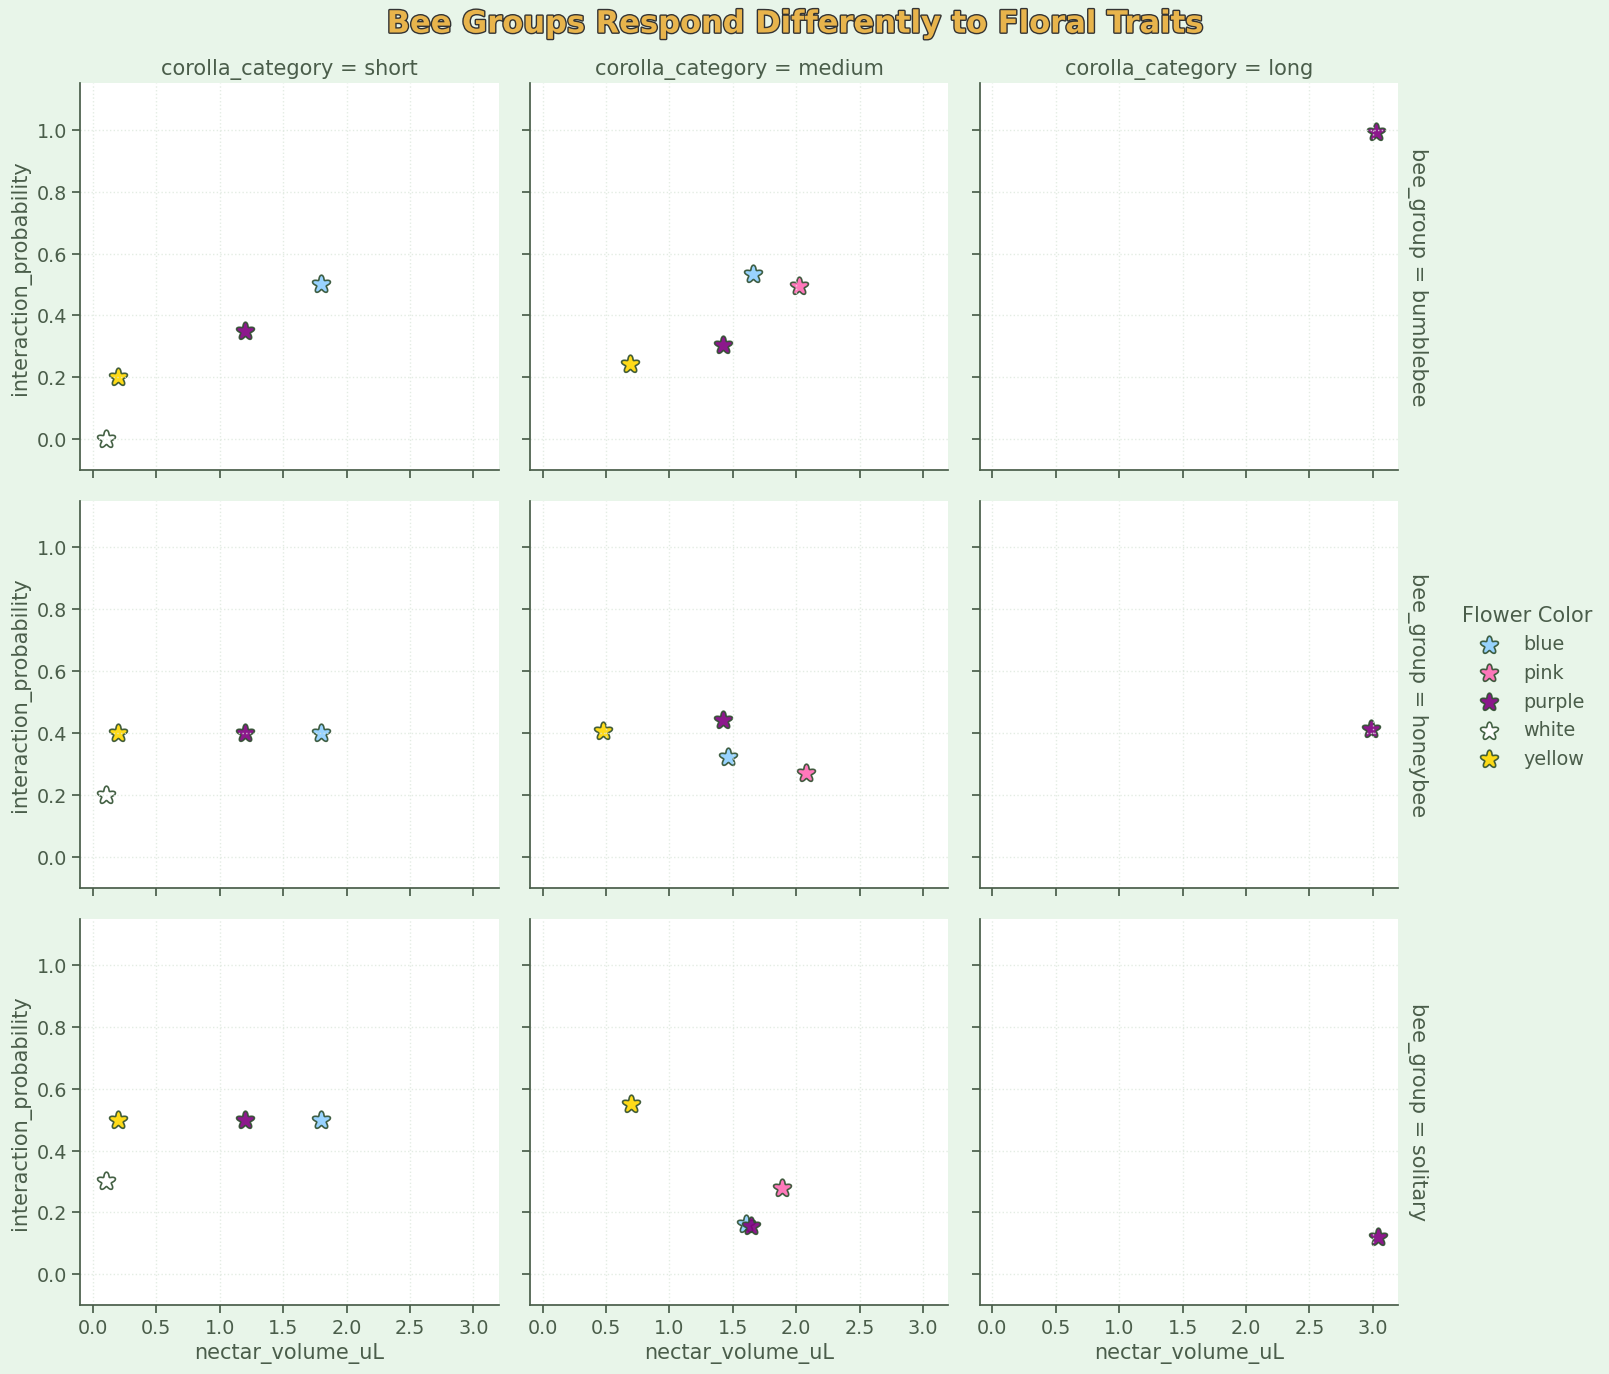

In [6]:
# @title
sns.set_theme(style=None, font_scale=1.25)

flower_palette = {
    "white": "#FFFFFF",
    "yellow": "#FFD700",
    "purple": "#800080",
    "pink": "#FF69B4",
    "blue": "#8ECFFF"
}



df_plot = (
    df.groupby(
        ["bee_group", "corolla_category", "flower_color"],
        observed=False
    )
    .agg({
        "nectar_volume_uL": "mean",
        "interaction_probability": "mean"
    })
    .reset_index()
)



g = sns.FacetGrid(
    df_plot,
    col="corolla_category",
    row="bee_group",
    hue="flower_color",
    palette=flower_palette,
    margin_titles=True,
    height=4.5,
    aspect=1.1,
)

g.map_dataframe(
    sns.scatterplot,
    x="nectar_volume_uL",
    y="interaction_probability",
    s=180,
    alpha=0.9,
    marker=flower_marker,
    edgecolor="#2F4F2F",
    linewidth=1.2
)

num_cols = len(g.col_names)

for i, ax in enumerate(g.axes.flatten()):
    col_index = i % num_cols

    for coll in ax.collections:
        offsets = coll.get_offsets()

        if col_index == 0:
            jitter_amount = 0.0
        elif col_index == 1:
            jitter_amount = 0.10
        else:
            jitter_amount = 0.05

        jitter = np.random.normal(0, jitter_amount, offsets.shape)
        coll.set_offsets(offsets + jitter)


# Axis limits
for ax in g.axes.flatten():
    ax.set_xlim(-0.1, 3.2)
    ax.set_ylim(-0.10, 1.15)


for ax, col in zip(g.axes[0], g.col_names):
    ax.set_title(f"corolla_category = {col}", color="#4A5D4A", pad=25)


# Light green background
g.fig.set_facecolor("#E8F5E9")

g.add_legend(title="Flower Color")

# --- MAKE EVERYTHING GREEN ---
for ax in g.axes.flatten():
    ax.xaxis.label.set_color("#4A5D4A")
    ax.yaxis.label.set_color("#4A5D4A")
    ax.tick_params(colors="#4A5D4A")
    ax.set_title(ax.get_title(), color="#4A5D4A")

    for spine in ax.spines.values():
        spine.set_color("#4A5D4A")

    ax.grid(True, linestyle=":", linewidth=1, color="#DDE8DD", alpha=0.8)

# RIGHT-SIDE tick labels
for ax in g.axes[:, -1]:
    for tick in ax.get_yticklabels():
        tick.set_color("#4A5D4A")

# Helper function to find all matplotlib.text.Text objects in the figure
def find_all_text_artists(fig):
    texts = []
    def get_texts_recursive(artist):
        if isinstance(artist, plt.Text):
            texts.append(artist)
        if hasattr(artist, 'get_children'):
            for child in artist.get_children():
                get_texts_recursive(child)
    get_texts_recursive(fig)
    return texts

# Color row titles on the right
row_title_labels = g.row_names
row_variable_name = "bee_group"

if row_variable_name:
    expected_full_titles_normalized = [f"{row_variable_name.lower()} = {name.lower()}" for name in row_title_labels]
    normalized_row_category_names = [name.lower() for name in row_title_labels]

    all_text_artists = find_all_text_artists(g.fig)

    for text_obj in all_text_artists:
        normalized_text_content = text_obj.get_text().strip().lower()

        if normalized_text_content in expected_full_titles_normalized or \
           any(category_name in normalized_text_content for category_name in normalized_row_category_names):
            text_obj.set_color("#4A5D4A")

# Legend
legend = g._legend
legend.get_title().set_color("#4A5D4A")
for text in legend.get_texts():
    text.set_color("#4A5D4A")

# Title
title = g.fig.suptitle(
    "Bee Groups Respond Differently to Floral Traits",
    fontsize=22,
    fontweight="bold",
    y=1.02,
    color="#E8B44C"
)

title.set_path_effects([
    path_effects.Stroke(linewidth=2, foreground='#333333'),
    path_effects.Normal()
])


plt.show()


This visualization compares how three bee groups respond to floral traits by examining interaction probability as a function of nectar volume (**0–3.0 µL**) across three corolla length categories. The figure highlights how floral morphology and nectar rewards jointly shape pollinator behavior.

**Corolla Length Effects**

Corolla length strongly influences accessibility:

🌺 Short corollas (nectar typically **0.1–0.3 µL**) show consistently moderate interaction probabilities (**0.10–0.30**) across all bee groups.

🌺 Medium corollas (nectar **0.5–1.5 µL**) produce more variable interactions (**0.20–0.70**) due to moderate morphological filtering.

🌺 Long corollas (nectar **2.0–3.0 µL**) generate the highest interaction probabilities, especially for bees capable of accessing deeper nectar reserves.

**Bee Group Differences**

Bee groups exhibit distinct behavioral and anatomical constraints:

🐝 Bumblebees achieve the highest interaction probabilities, often exceeding **0.90** on long corollas.

🐝 Honeybees show moderate interactions, typically remaining below **0.60** on long corollas due to shorter tongues.

🐝 Solitary bees frequently fall below **0.40**, especially when nectar volume is under **1.0 µL**, indicating stronger morphological limitations.

**Nectar Volume Influence**

Across all bee groups, interaction probability increases with nectar volume. A notable threshold occurs around **2.0 µL**, where interaction probability rises sharply, particularly for bumblebees, suggesting that higher nectar rewards strongly incentivize visitation.

**Flower Color Patterns**

Flower color acts as a visual cue rather than a direct determinant of interaction probability.
However, color distribution aligns with nectar availability:

🌼 White and yellow flowers are common in the **0.1–0.3 µL** range.

🪻 Purple and blue flowers appear more frequently above **2.0 µL**, potentially signaling higher rewards or targeting specific pollinators.

### **Interpretation**

Overall, the figure demonstrates that pollinator–flower interactions are shaped by the interplay of floral morphology, nectar availability, and pollinator traits.

**Bumblebees emerge as the most versatile pollinators, while honeybees and solitary bees show stronger trait‑based constraints.**

The numeric patterns reinforce that deeper corollas and higher nectar volumes (**> 2.0 µL**) disproportionately benefit larger, long‑tongued pollinators.

### 🐝 Bee Attraction by Flower Species 🌷

By averaging interaction probability for each flower, we can see which species naturally draw more pollinator attention.

In [7]:
# @title
df.groupby('flower_common_name')['interaction_probability'].mean().sort_values(ascending=False)



,interaction_probability
flower_common_name,
Foxglove,0.51
Lacy Phacelia,0.48
Lavender,0.42
Dandelion,0.36
Sunflower,0.36
Viper's Bugloss,0.36
Red Clover,0.34
Harebell,0.33
Sage,0.30


# **🌼 Flower Species in This Dataset (ordered by pollinator preference)**



### 🌺 **#1 Foxglove (Digitalis purpurea)**

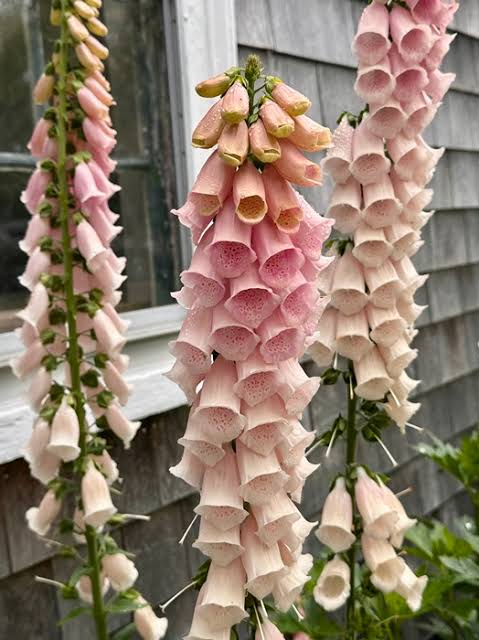

**Best for:** Long‑tongued bees, bumblebees, hummingbirds  

**Flower type:** Tall spikes with tubular bells  

**Bloom time:** Late spring to early summer

**Environment notes:** Needs shade or partial shade, prefers cooler climates, likes moist, rich soil, hates hot, dry summers

**Pollinator note:** Deep tubular flowers favor bees with longer tongues and provide shelter while feeding.  

**Similar flowers:**
Snapdragon, Columbine, Monkshood, Delphinium, Lupine, Salvia, Campanula, Coral Bells, Beard Tongue



### 💜 **#2 Lacy Phacelia (Phacelia tanacetifolia)**

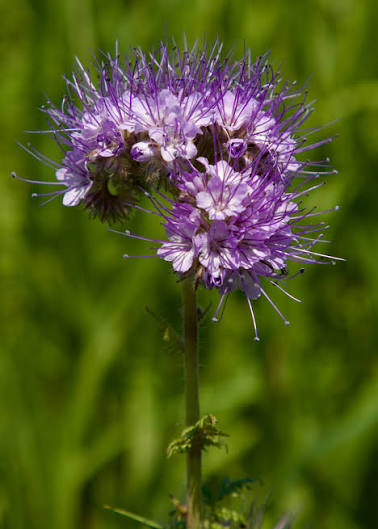

**Best for:** Honey bees, native solitary bees, hoverflies  

**Flower type:** Curled clusters of many small blooms  

**Bloom time:** Early to mid‑summer  

**Environment notes:** Needs full sun, prefers dry or semi‑dry soil, thrives in well‑drained ground, tolerates poor soil, hates waterlogged conditions.

**Pollinator note:** Extremely nectar‑rich; often used as a cover crop and bee forage plant.  

**Similar flowers:** Borage, Bluebells, Scorpionweed, Forget‑Me‑Not, Cornflower, Chicory, Viper’s Bugloss, Lavender Hyssop, Catmint, Wild Blue Phlox  



  


### 💜 **#3 Lavender (Lavandula angustifolia)**

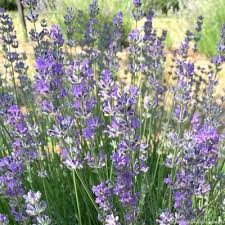

**Best for:** Honey bees, bumblebees, butterflies  

**Flower type:** Spikes of fragrant purple blooms  

**Bloom time:** Summer  

**Environment notes:** Needs full sun, prefers warm climates, requires dry well‑drained soil, hates wet roots, struggles in heavy clay

**Pollinator note:** High nectar, strong scent, and repeated blooms make it a pollinator magnet.

**Similar flowers:** Russian Sage, Catmint, Hyssop, Bee Balm, Rosemary, Thyme, Oregano, Sage, Lamb’s Ear, Bluebeard  




### 🌼 **#4 Dandelion (Taraxacum officinale)**

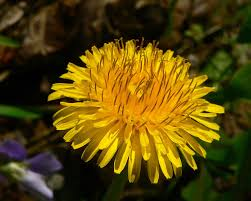

**Best for:** Early‑season bees, hoverflies  

**Flower type:** Bright yellow composite flower  

**Bloom time:** Very early spring through fall  

**Pollinator note:** One of the first nectar and pollen sources when little else is blooming.  

**Similar flowers:** Hawkweed, Chicory, Coltsfoot, Plantain, Black‑Eyed Susan, Coreopsis, Goldenrod, Aster, Sunflower, Coneflower  



### 🌻 **#5 Sunflower (Helianthus annuus)**

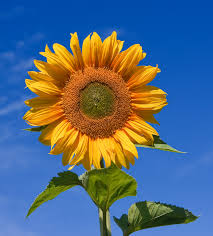

**Best for:** Bees, butterflies, birds (seeds)

**Flower type:** Large composite flower with many florets  

**Bloom time:** Summer to early fall  

**Pollinator note:** Each “flower” is actually hundreds of tiny florets—massive nectar and pollen resource.

**Similar flowers:** Coneflower, Black‑Eyed Susan, Rudbeckia, Coreopsis, Gaillardia, Zinnia, Cosmos, Aster, Goldenrod, Joe‑Pye Weed  


### 🌿 **#6 Sage (Salvia officinalis)**

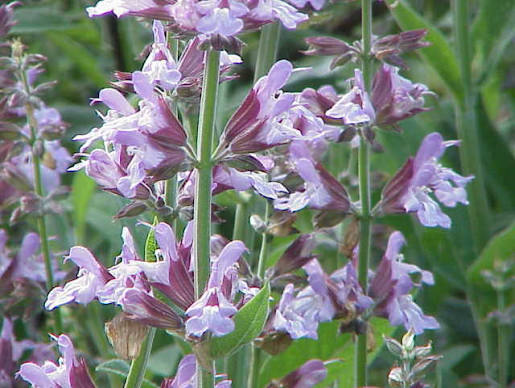

**Best for:** Bees, butterflies, hummingbirds (ornamental salvias)  

**Flower type:** Spikes of small tubular flowers  

**Bloom time:** Late spring to summer  

**Environment notes:** Needs full sun, prefers warm dry climates, likes sandy or rocky soil, hates constant moisture, struggles in heavy wet soil

**Pollinator note:** Tubular flowers and strong scent attract bees and hummingbirds; herbs double as culinary plants.  

**Similar flowers:** Salvia (all varieties), Bee Balm, Hyssop, Catmint, Penstemon, Veronica, Lavender, Rosemary, Thyme, Oregano  

### ❤️ **#7 Red Clover (Trifolium pratense)**

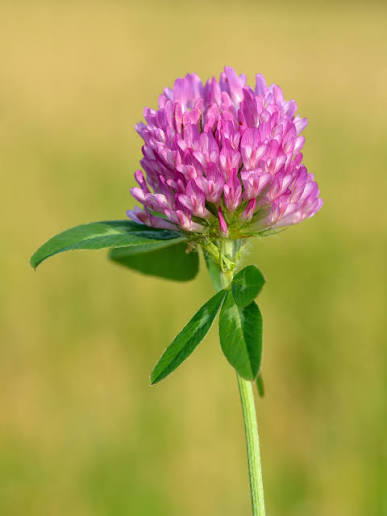

**Best for:** Bumblebees, long‑tongued bees

**Flower type:** Rounded clusters of many tiny florets  

**Bloom time:** Spring through fall (in meadows and lawns)  

**Pollinator note:** Classic forage plant; deep florets favor bees with longer tongues.  

**Similar flowers:** White Clover, Crimson Clover, Alsike Clover, Vetch, Alfalfa, Cowpea, Lupine, Bird’s‑Foot Trefoil, Sweet Clover, Milk Vetch  




### 🔔 **#8 Harebell (Campanula rotundifolia)**

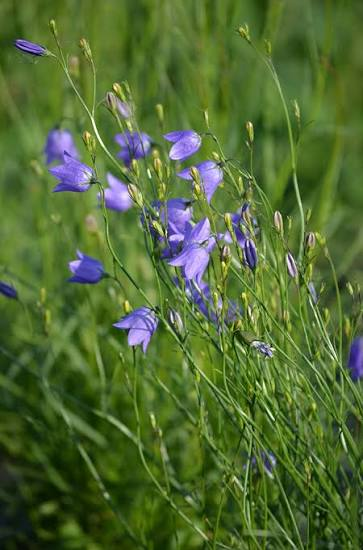

**Best for:** Bees, small butterflies  

**Flower type:** Nodding bell‑shaped flowers  

**Bloom time:** Summer  

**Environment notes:** Needs full sun or partial shade, prefers cool climates, likes rocky or sandy soil, requires good drainage, struggles in heavy clay

**Pollinator note:** Delicate bells provide nectar to small bees and insects in rocky or meadow habitats.  

**Similar flowers:** Campanula (all varieties), Balloon Flower, Bluebells, Lobelia, Phlox, Delphinium, Columbine, Penstemon, Gentian, Jacob’s Ladder  


### 💙 **#9 Viper’s Bugloss (Echium vulgare)**

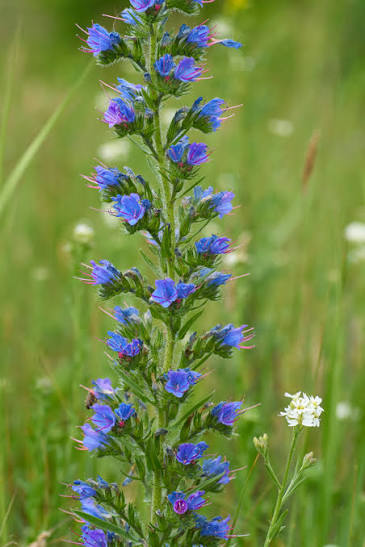

**Best for:** Honey bees, bumblebees, butterflies  

**Flower type:** Spikes of blue‑purple tubular flowers  

**Bloom time:** Summer  

**Environment notes:** Needs full sun, prefers dry sandy or rocky soil, thrives in poor soil, tolerates drought, hates rich wet soil

**Pollinator note:** Extremely nectar‑rich; bees revisit plants repeatedly during bloom.  

**Similar flowers:** Borage, Blueweed, Hyssop, Catmint, Lavender Hyssop, Russian Sage, Bluebeard, Salvia, Penstemon, Wild Blue Phlox  



### 🌼 **#10 Common Daisy (Bellis perennis)**

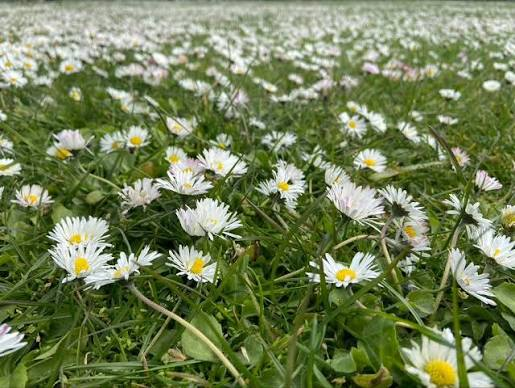

**Best for:** Bees, hoverflies, beetles  

**Flower type:** Composite flower with central disc and white rays  

**Bloom time:** Spring to fall  

**Pollinator note:** Simple open structure makes nectar and pollen easy to access for many insect species.  

**Similar flowers:** Oxeye Daisy, Shasta Daisy, Aster, Fleabane, Chamomile, Yarrow, Coreopsis, Black‑Eyed Susan, Coneflower, Blanket Flower

# 🪷 Top 10 Flowers That Bees Love (outside of this project) 🐝💛


Understanding which flowers bees prefer in real ecosystems helps validate and contextualize the synthetic interaction probabilities in this study. The following list represents species consistently ranked highly across horticultural, ecological, and pollinator‑conservation sources. These flowers provide reliable nectar, accessible floral structures, and strong visual cues that align with bee foraging behavior.

🌷 **Bee Balm (Monarda)** — tubular blooms rich in nectar; attracts bumblebees and long‑tongued species.

🌷 **Coneflower (Echinacea)** — large composite heads with abundant pollen; highly attractive to native bees.

🌷 **Aster (Symphyotrichum spp.)** — late‑season nectar source; critical for fall foraging.

🌷 **Lavender (Lavandula)** — strong scent, high nectar reward, and easy access for many bee groups.

🌷 **Sunflower (Helianthus)** — pollen powerhouse; supports solitary bees and bumblebees.

🌷 **Goldenrod (Solidago)** — extremely high nectar production; supports massive pollinator diversity.

🌷 **Borage (Borago officinalis)** — refills nectar rapidly; bees revisit repeatedly.

🌷 **Salvia (Salvia spp.)** — tubular corollas favored by long‑tongued bees; high nectar concentration.

🌷 **Black‑Eyed Susan (Rudbeckia)** — composite structure with accessible pollen; attracts generalist bees.

🌷 **Zinnia / Cosmos** — bright colors and open floral architecture; excellent for honeybees and native bees.

### 🧩 Comparison With This Project’s Dataset

My synthetic dataset includes several species that overlap with real‑world bee favorites (Lavender, Sunflower, Salvia).
This alignment strengthens ecological validity and shows that my model captures meaningful floral traits.

| Rank | Flower              | In Dataset? | Notes                                      |
|------|---------------------|-------------|--------------------------------------------|
| 1    | Bee Balm            | ❌          | Top nectar producer; attracts many species |
| 2    | Coneflower          | ❌          | Strong pollinator magnet                   |
| 3    | Aster               | ❌          | Critical late-season resource              |
| 4    | Lavender            | ✅          | High nectar, strong scent, easy access     |
| 5    | Sunflower           | ✅          | Pollen-rich composite head                 |
| 6    | Goldenrod           | ❌          | Extremely high nectar output               |
| 7    | Borage              | ❌          | Rapid nectar refill; bees revisit often    |
| 8    | Salvia              | ✅          | Long‑tongued bee specialist                |
| 9    | Black‑Eyed Susan    | ❌          | Generalist bee favorite                    |
| 10   | Zinnia / Cosmos     | ❌          | Bright colors, open structure              |




### 🌎 Ecological Interpretation

The overlap between my dataset and bee favorites highlights that my engineered traits **(color, symmetry, nectar volume, corolla length)** reflect genuine pollinator preferences.
The missing species represent excellent candidates for future dataset expansion, especially if I want to model seasonal foraging patterns or multi‑species pollinator networks.

# **Conclusion**
Flower species differed widely in their ability to draw pollinators, with plants like **Foxglove, Phacelia, and Lavender** standing out as high‑interaction species. These patterns highlight how thoughtful plant selection can meaningfully support pollinator diversity.

Across the trait space, different bee groups responded in distinct ways: **bumblebees showed the broadest ability to handle varied floral structures**, while honeybees and solitary bees tended to be more limited by corolla depth, nectar accessibility, and symmetry. These contrasts reveal how floral traits shape not just overall visitation, but the composition of pollinator communities.

Overall, this project demonstrates how ecological data and feature engineering can uncover the mechanisms that connect pollinators to the plants they depend on, and how small, informed choices in habitat design can strengthen entire ecosystems. 💚